# **E-commerce Sales & Customer Insights (EDA)**

**1. Import Libraries**

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

**2. Load Dataset**

In [5]:
# Load the built-in 'tips' dataset from Seaborn library
df = sns.load_dataset('tips')

print("--- Initial Data ---")
print(df.head())


--- Initial Data ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


**3. Handle missing values and removed dublicate rows**

In [12]:
# Load the built-in 'tips' dataset from Seaborn library
df = sns.load_dataset('tips')

print("--- Initial Data ---")
print(df.head())

# Task: Checking for Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# Check for duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

# Removing duplicates if any exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows successfully removed!")
else:
    print("No duplicates to remove.")

--- Initial Data ---
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Missing Values:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
Total duplicate rows found: 1
Duplicate rows successfully removed!


**4: Data Cleaning aur Outliers**

Interquartile Range (IQR): 10.779999999999998
Typical bill range (Q1 to Q3): 13.3475 to 24.127499999999998


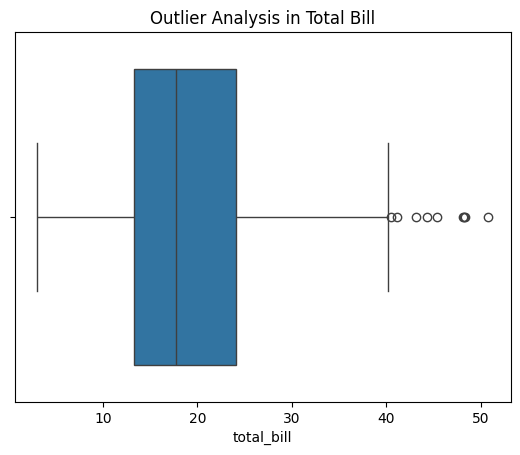

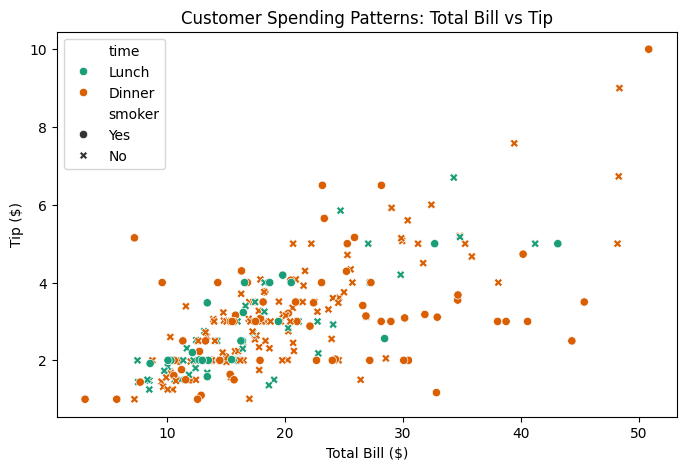

/tmp/ipykernel_2154/676474571.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='day', y='total_bill', estimator=sum, errorbar=None, palette='muted')


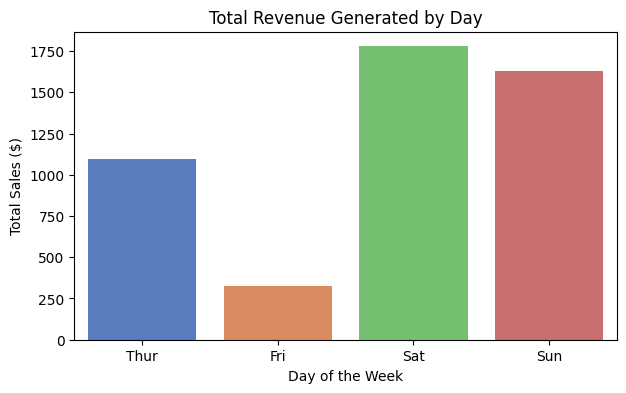

In [6]:
# Calculate the Interquartile Range (IQR) for 'total_bill' to identify outliers
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

print(f"Interquartile Range (IQR): {IQR}")
print(f"Typical bill range (Q1 to Q3): {Q1} to {Q3}")

# Visualize outliers using a Boxplot
sns.boxplot(x=df['total_bill'])
plt.title('Outlier Analysis in Total Bill')
plt.show()

#Advanced Seaborn Plots for Customer Insights
# 1. Total Bill vs Tip (Scatter Plot with Hue)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', style='smoker', palette='Dark2')
plt.title('Customer Spending Patterns: Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

# 2. Day-wise Sales Distribution (Bar Plot)
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='day', y='total_bill', estimator=sum, errorbar=None, palette='muted')
plt.title('Total Revenue Generated by Day')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales ($)')
plt.show()

**4: Data Preprocessing (Encoding & Engineering)**

In [7]:
# Convert categorical text data into numerical codes for Machine Learning
# 0 = Female, 1 = Male
df['sex_code'] = df['sex'].map({'Female': 0, 'Male': 1})
# 0 = Non-Smoker, 1 = Smoker
df['smoker_code'] = df['smoker'].map({'No': 0, 'Yes': 1})

# Feature Engineering: Calculate tip percentage relative to the total bill
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100

# Display the newly created features
print("--- Feature Engineering Results ---")
print(df[['total_bill', 'tip', 'sex_code', 'tip_percentage']].head())

#Feature Scaling
from sklearn.preprocessing import StandardScaler
# Un numerical features ki list jinpar scaling apply karni hai
numerical_features = ['total_bill', 'tip', 'tip_percentage']

scaler = StandardScaler()
df_scaled = df.copy()

# Data ko scale karna
df_scaled[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\n--- Scaled Numerical Data Features ---")
print(df_scaled[numerical_features].head())

--- Feature Engineering Results ---
   total_bill   tip sex_code  tip_percentage
0       16.99  1.01        0        5.944673
1       10.34  1.66        1       16.054159
2       21.01  3.50        1       16.658734
3       23.68  3.31        1       13.978041
4       24.59  3.61        0       14.680765

--- Scaled Numerical Data Features ---
   total_bill       tip  tip_percentage
0   -0.314711 -1.439947       -1.663018
1   -1.063235 -0.969205       -0.004282
2    0.137780  0.363356        0.094915
3    0.438315  0.225754       -0.344926
4    0.540745  0.443020       -0.229625


**5.Categorical Encoding & Data Splitting**

In [11]:
from sklearn.model_selection import train_test_split

# Baki categorical features (jaise day aur time) ko dummy encoding (One-Hot Encoding) dena
df_final = pd.get_dummies(df_scaled, columns=['day', 'time', 'sex', 'smoker'], drop_first=True)

# Target variable aur features ko alag karna
X = df_final.drop(columns=['tip'])
y = df_final['tip']

# ⚠️ YAHAN FIX KIYA HAI: 'test_test_split' ko 'test_size' kar diya hai
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Splitting Successfully Executed ---")
print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape} | y_test Shape: {y_test.shape}")

--- Data Splitting Successfully Executed ---
X_train Shape: (195, 11) | X_test Shape: (49, 11)
y_train Shape: (195,) | y_test Shape: (49,)


**5: Exploratory Data Visualization**

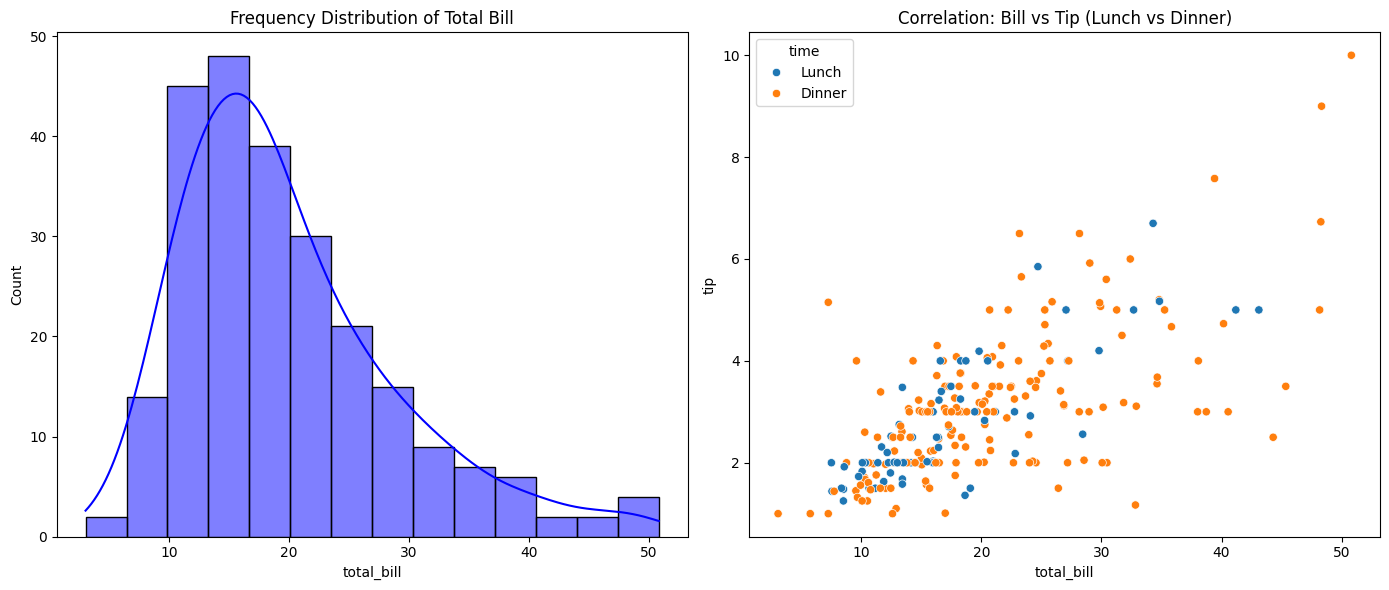

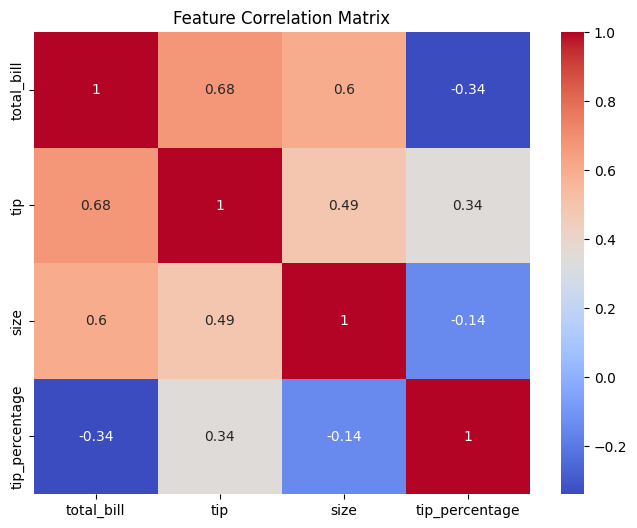

In [ ]:
# Set the figure size for better visibility
plt.figure(figsize=(14, 6))

# Subplot 1: Distribution of the total bill amount
plt.subplot(1, 2, 1)
sns.histplot(df['total_bill'], kde=True, color='blue')
plt.title('Frequency Distribution of Total Bill')

# Subplot 2: Relationship between Bill and Tip, categorized by time of day
plt.subplot(1, 2, 2)
sns.scatterplot(x='total_bill', y='tip', hue='time', data=df)
plt.title('Correlation: Bill vs Tip (Lunch vs Dinner)')

plt.tight_layout()
plt.show()

# Heatmap to check the correlation between all numerical columns
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

**6: Summary and Business Insights**

In [ ]:
# Print final insights for stakeholders or project managers
print("--- Final Project Summary ---")
print(f"Dataset Size: {len(df)} records")
print(f"Average Tip Amount: ${df['tip'].mean():.2f}")
print(f"Maximum Single Bill: ${df['total_bill'].max()}")
print(f"Peak Business Time: {df['time'].mode()[0]}")

--- Final Project Summary ---
Dataset Size: 244 records
Average Tip Amount: $3.00
Maximum Single Bill: $50.81
Peak Business Time: Dinner
